# Exploration of Integrating Sphere Illumination Pattern


In [1]:
import numpy as np
import matplotlib.pyplot as plt

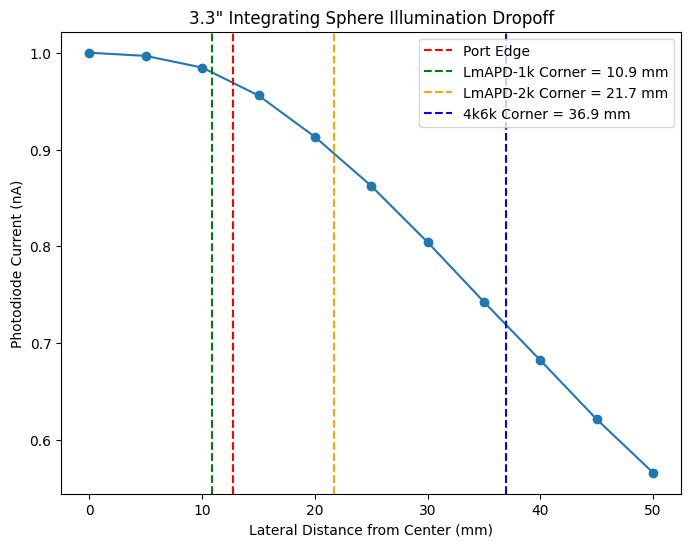

In [5]:
# 3.3" Sphere: Illumination Dropoff

d_z = 4.0*25.4 #in

d_x = [ 0,
       5.0,
       10.0,
       15.0,
       20.0,
       25.0,
       30.0,
       35.0,
       40.0,
       45.0,
       50.0,
       ]

Ipd = [ 27.38,
       27.29,
       26.96,
       26.17,
       25.0,
       23.61,
       22.02,
       20.33,
       18.68,
       17.01,
       15.50,

       
]

# normalize Ipd
Ipd_norm = Ipd / np.max(Ipd)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(d_x, Ipd_norm, 'o-')
ax.set_xlabel("Lateral Distance from Center (mm)")
ax.set_ylabel("Photodiode Current (nA)")
ax.set_title("3.3\" Integrating Sphere Illumination Dropoff")

# put a vertical line at half the port diameter
port_diameter = 1.0 * 25.4 # in -> mm
ax.axvline(port_diameter/2, color='r', linestyle='--', label='Port Edge')


# put a vertical line for the corner of the LmAPD detector
lmapd1k_wx = 1024*0.015/2 # mm
lmapd1k_wy = lmapd1k_wx
lmapd1k_r = np.sqrt(lmapd1k_wx**2 + lmapd1k_wy**2)
ax.axvline(lmapd1k_r, color='g', linestyle='--', label=f'LmAPD-1k Corner = {lmapd1k_r:.1f} mm')

lmapd2k_wx = 2048*0.015/2 # mm
lmapd2k_wy = lmapd2k_wx
lmapd2k_r = np.sqrt(lmapd2k_wx**2 + lmapd2k_wy**2)
ax.axvline(lmapd2k_r, color='orange', linestyle='--', label=f'LmAPD-2k Corner = {lmapd2k_r:.1f} mm')


mosaic4k6k_wx = 4096*0.01/2 # mm
mosaic4k6k_wy = 6144*0.01/2 # mm
mosaic4k6k_r = np.sqrt(mosaic4k6k_wx**2 + mosaic4k6k_wy**2)
ax.axvline(mosaic4k6k_r, color='b', linestyle='--', label=f'4k6k Corner = {mosaic4k6k_r:.1f} mm')

ax.legend()
plt.show()



In [3]:

# zemax model data


zmx_x = [0,
          5.52,
          10.22,
          14.72,
          20.85,
          25.15,
          30.26,
          35.17,
          39.67,
          44.98,
          49.68,
          55.41,
       ]
zmx_dist = 127.0
zmx_theta = np.arctan(np.array(zmx_x) / zmx_dist)
zmx_irr = [ 0.0008545,
       0.0008593,
       0.0008333,
       0.0008128,
       0.0007779,
       0.0007313,
       0.0006844,
       0.0006485,
       0.0005737,
       0.0005271,
       0.0004771,
       0.0004267,

       ]
zmx_irr_norm = zmx_irr / np.max(zmx_irr)


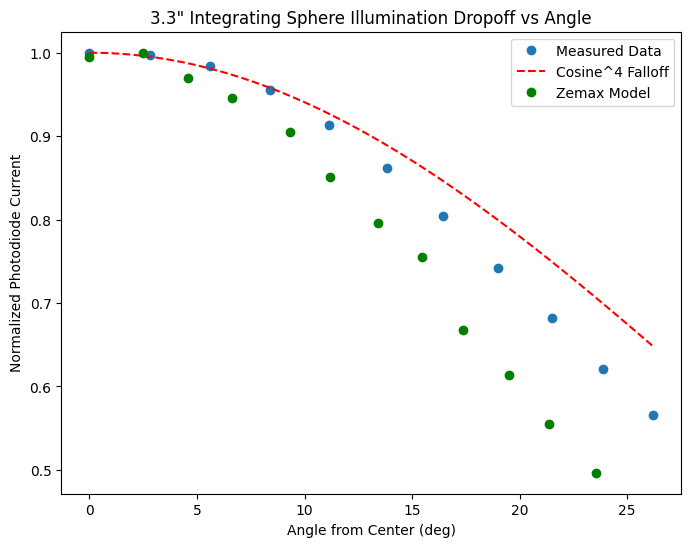

In [4]:
# plot the cos^4 falloff for comparison
theta = np.arctan(np.array(d_x) / d_z)
theta_deg = np.degrees(theta)
theta_fine = np.linspace(0, np.max(theta), 100)
Ipd_cos4 = np.cos(theta_fine) ** 4
Ipd_cos4_norm = Ipd_cos4 / np.max(Ipd_cos4) # normalize 
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(theta_deg, Ipd_norm, 'o', label='Measured Data')
ax.plot(np.degrees(theta_fine), Ipd_cos4_norm, 'r--', label='Cosine^4 Falloff')
ax.plot(np.degrees(zmx_theta), zmx_irr_norm, 'go', label='Zemax Model')
ax.set_xlabel("Angle from Center (deg)")
ax.set_ylabel("Normalized Photodiode Current")
ax.set_title("3.3\" Integrating Sphere Illumination Dropoff vs Angle")
ax.legend()
plt.show()